<a href="https://colab.research.google.com/github/mbenedicto99/Canopus/blob/main/Artemis_Jupiter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A melhor visualização é mostrar:

a nave se aproximando de Júpiter,
a força/aceleração gravitacional aumentando,
a comparação com a gravidade da Terra,
e uma trajetória tipo flyby ou queda direta.

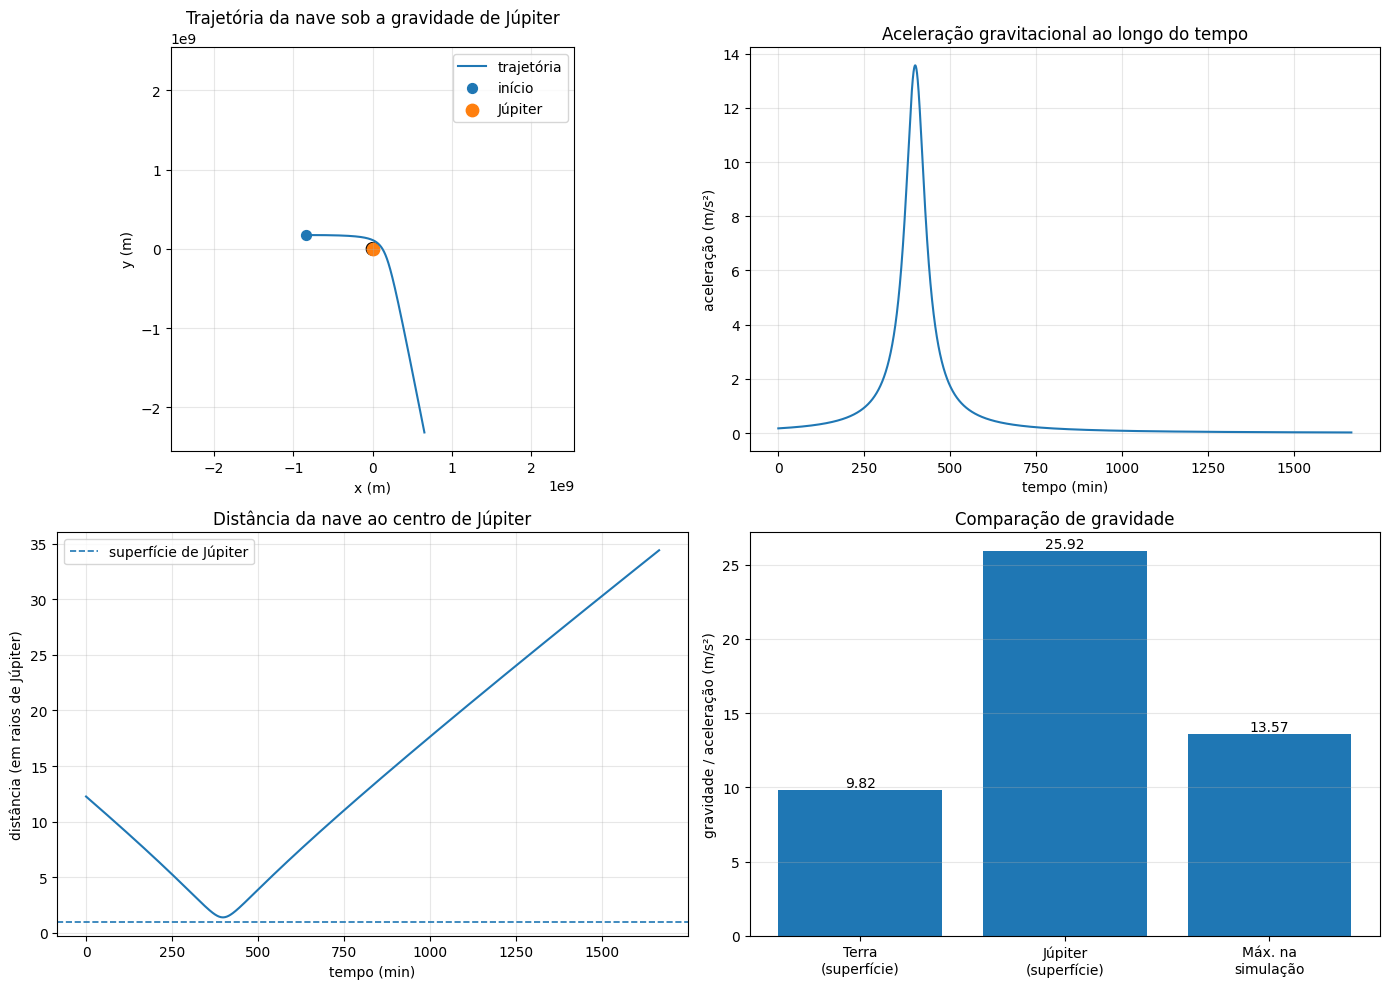

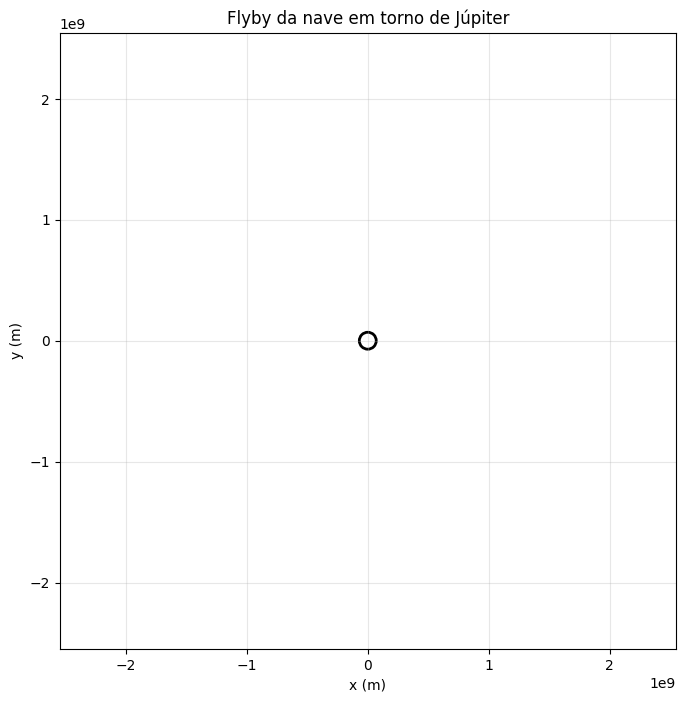


Resumo da simulação
----------------------------------------
Gravidade na superfície da Terra   : 9.82 m/s²
Gravidade na superfície de Júpiter : 25.92 m/s²
Menor distância da nave            : 1.38 Rj
Maior aceleração na simulação      : 13.57 m/s²
Maior aceleração em 'g' terrestre  : 1.38 g
A nave não colidiu com Júpiter.


In [1]:
# -*- coding: utf-8 -*-
"""
Simulação didática da gravidade de Júpiter agindo sobre uma nave tipo Artemis II.

Requisitos:
    pip install numpy matplotlib

Execute:
    python jupiter_gravity_artemis.py
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================
# Constantes
# =========================
G = 6.67430e-11              # m^3 kg^-1 s^-2
M_JUPITER = 1.898e27         # kg
R_JUPITER = 6.9911e7         # m
M_EARTH = 5.9722e24          # kg
R_EARTH = 6.371e6            # m

# Nave Artemis II / Orion (massa ilustrativa)
M_SHIP = 26000               # kg

# =========================
# Configuração inicial
# =========================
# Posição inicial da nave: 12 raios de Júpiter
r0 = np.array([-12 * R_JUPITER, 2.5 * R_JUPITER])

# Velocidade inicial para flyby
v0 = np.array([32000.0, 0.0])   # m/s

# Tempo
dt = 20.0
steps = 5000

# =========================
# Funções
# =========================
def acceleration(r):
    dist = np.linalg.norm(r)
    if dist == 0:
        return np.zeros(2)
    return -G * M_JUPITER * r / dist**3

def rk4_step(r, v, dt):
    def f_r(vv):
        return vv

    def f_v(rr):
        return acceleration(rr)

    k1_r = f_r(v)
    k1_v = f_v(r)

    k2_r = f_r(v + 0.5 * dt * k1_v)
    k2_v = f_v(r + 0.5 * dt * k1_r)

    k3_r = f_r(v + 0.5 * dt * k2_v)
    k3_v = f_v(r + 0.5 * dt * k2_r)

    k4_r = f_r(v + dt * k3_v)
    k4_v = f_v(r + dt * k3_r)

    r_next = r + (dt / 6.0) * (k1_r + 2*k2_r + 2*k3_r + k4_r)
    v_next = v + (dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)

    return r_next, v_next

def gravity_magnitude(r):
    d = np.linalg.norm(r)
    return G * M_JUPITER / d**2

def surface_gravity(M, R):
    return G * M / R**2

# =========================
# Simulação
# =========================
positions = []
velocities = []
accels = []
distances = []
times = []

r = r0.copy()
v = v0.copy()

collision = False
collision_step = None

for i in range(steps):
    positions.append(r.copy())
    velocities.append(v.copy())
    accels.append(np.linalg.norm(acceleration(r)))
    distances.append(np.linalg.norm(r))
    times.append(i * dt)

    if np.linalg.norm(r) <= R_JUPITER:
        collision = True
        collision_step = i
        break

    r, v = rk4_step(r, v, dt)

positions = np.array(positions)
velocities = np.array(velocities)
accels = np.array(accels)
distances = np.array(distances)
times = np.array(times)

# =========================
# Métricas
# =========================
g_jupiter_surface = surface_gravity(M_JUPITER, R_JUPITER)
g_earth_surface = surface_gravity(M_EARTH, R_EARTH)

min_dist = distances.min()
min_dist_rj = min_dist / R_JUPITER
max_accel = accels.max()
max_accel_in_g = max_accel / 9.80665

# =========================
# Visualização principal
# =========================
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

# 1. Trajetória
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Trajetória da nave sob a gravidade de Júpiter")

jupiter = plt.Circle((0, 0), R_JUPITER, fill=False, linewidth=2)
ax1.add_patch(jupiter)

ax1.plot(positions[:, 0], positions[:, 1], linewidth=1.5, label="trajetória")
ax1.scatter(positions[0, 0], positions[0, 1], s=50, label="início")
ax1.scatter(0, 0, s=80, label="Júpiter")

limit = max(np.max(np.abs(positions[:, 0])), np.max(np.abs(positions[:, 1])), 13 * R_JUPITER)
ax1.set_xlim(-1.1 * limit, 1.1 * limit)
ax1.set_ylim(-1.1 * limit, 1.1 * limit)
ax1.set_aspect("equal", adjustable="box")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Aceleração gravitacional ao longo do tempo
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Aceleração gravitacional ao longo do tempo")
ax2.plot(times / 60, accels, linewidth=1.5)
ax2.set_xlabel("tempo (min)")
ax2.set_ylabel("aceleração (m/s²)")
ax2.grid(True, alpha=0.3)

# 3. Distância até o centro de Júpiter
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Distância da nave ao centro de Júpiter")
ax3.plot(times / 60, distances / R_JUPITER, linewidth=1.5)
ax3.axhline(1.0, linestyle="--", linewidth=1.2, label="superfície de Júpiter")
ax3.set_xlabel("tempo (min)")
ax3.set_ylabel("distância (em raios de Júpiter)")
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Comparação com Terra e valor máximo da simulação
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_title("Comparação de gravidade")
labels = ["Terra\n(superfície)", "Júpiter\n(superfície)", "Máx. na\nsimulação"]
values = [g_earth_surface, g_jupiter_surface, max_accel]
bars = ax4.bar(labels, values)
ax4.set_ylabel("gravidade / aceleração (m/s²)")
ax4.grid(True, axis="y", alpha=0.3)

for bar, v in zip(bars, values):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# =========================
# Animação
# =========================
fig2, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Flyby da nave em torno de Júpiter")

jupiter2 = plt.Circle((0, 0), R_JUPITER, fill=False, linewidth=2)
ax.add_patch(jupiter2)

trail, = ax.plot([], [], linewidth=1.2)
ship, = ax.plot([], [], marker="o", markersize=6)

ax.set_xlim(-1.1 * limit, 1.1 * limit)
ax.set_ylim(-1.1 * limit, 1.1 * limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.grid(True, alpha=0.3)

def init():
    trail.set_data([], [])
    ship.set_data([], [])
    return trail, ship

def update(frame):
    trail.set_data(positions[:frame, 0], positions[:frame, 1])
    ship.set_data([positions[frame, 0]], [positions[frame, 1]])
    return trail, ship

ani = FuncAnimation(
    fig2,
    update,
    frames=len(positions),
    init_func=init,
    interval=20,
    blit=True
)

plt.show()

# =========================
# Resumo
# =========================
print("\nResumo da simulação")
print("-" * 40)
print(f"Gravidade na superfície da Terra   : {g_earth_surface:.2f} m/s²")
print(f"Gravidade na superfície de Júpiter : {g_jupiter_surface:.2f} m/s²")
print(f"Menor distância da nave            : {min_dist_rj:.2f} Rj")
print(f"Maior aceleração na simulação      : {max_accel:.2f} m/s²")
print(f"Maior aceleração em 'g' terrestre  : {max_accel_in_g:.2f} g")

if collision:
    print(f"A nave colidiu com Júpiter no passo {collision_step}.")
else:
    print("A nave não colidiu com Júpiter.")

Como estudar melhor com esse script

Altere estes pontos:

1. Queda direta
v0 = np.array([0.0, 0.0])

2. Passagem próxima
v0 = np.array([28000.0, 0.0])

3. Passagem mais aberta
v0 = np.array([38000.0, 0.0])

4. Aproximação mais agressiva
r0 = np.array([-8 * R_JUPITER, 1.2 * R_JUPITER])

O que você vai enxergar
quanto mais a nave se aproxima, mais a curva da trajetória fecha
a aceleração cresce muito perto do planeta
Júpiter tem gravidade superficial maior que a da Terra, mas o efeito mais interessante aparece no campo gravitacional em torno dele, não só na superfície

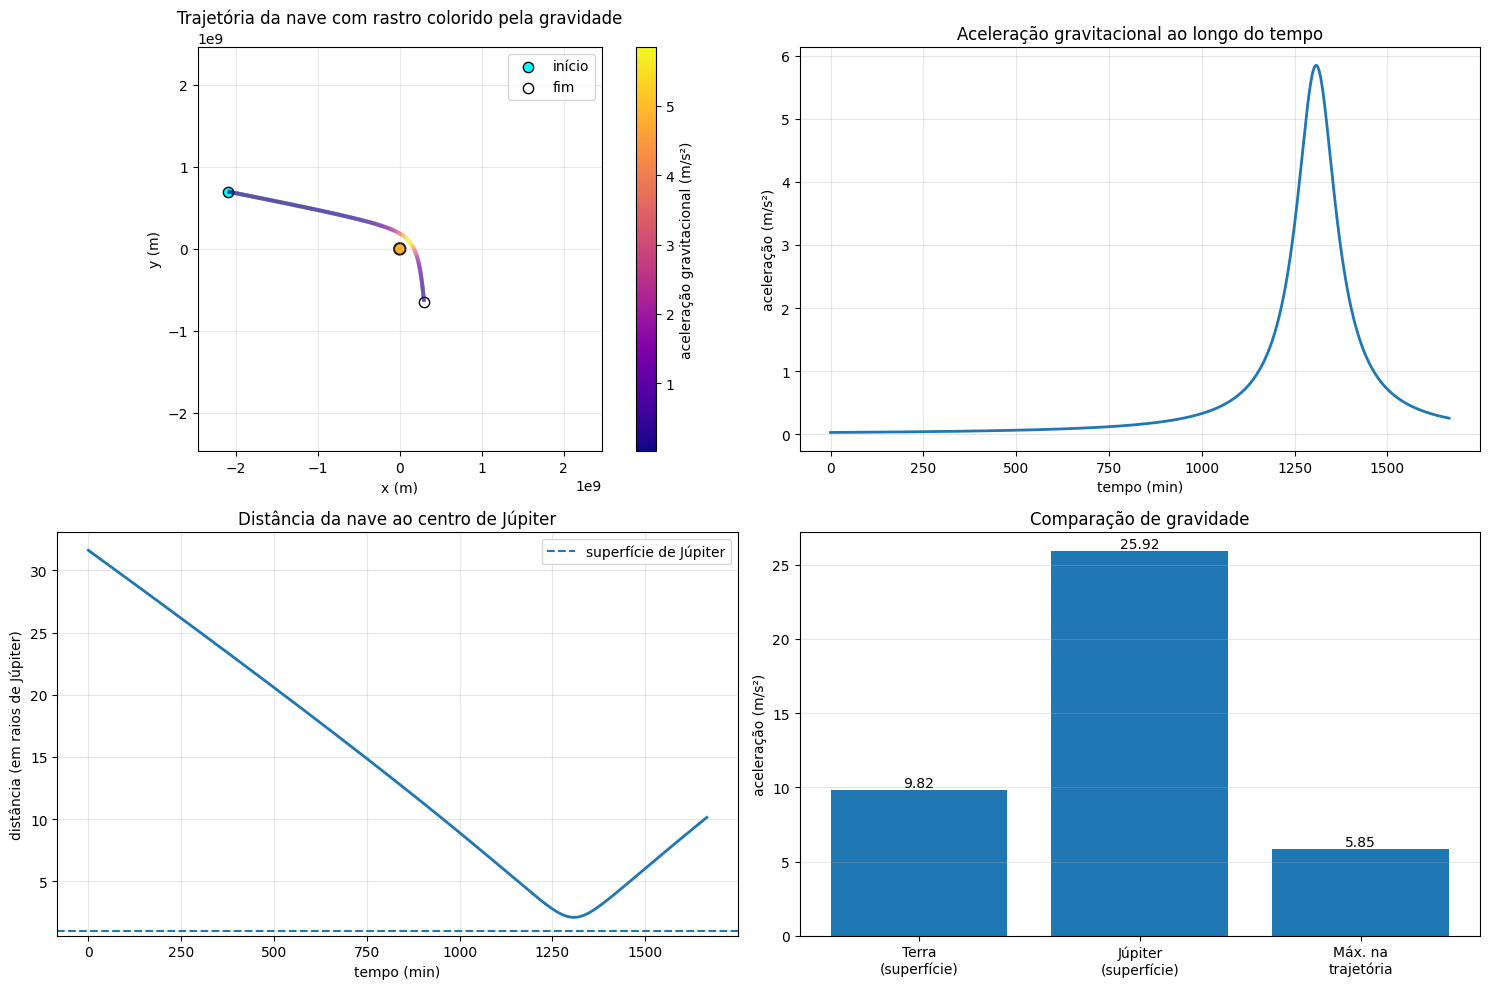

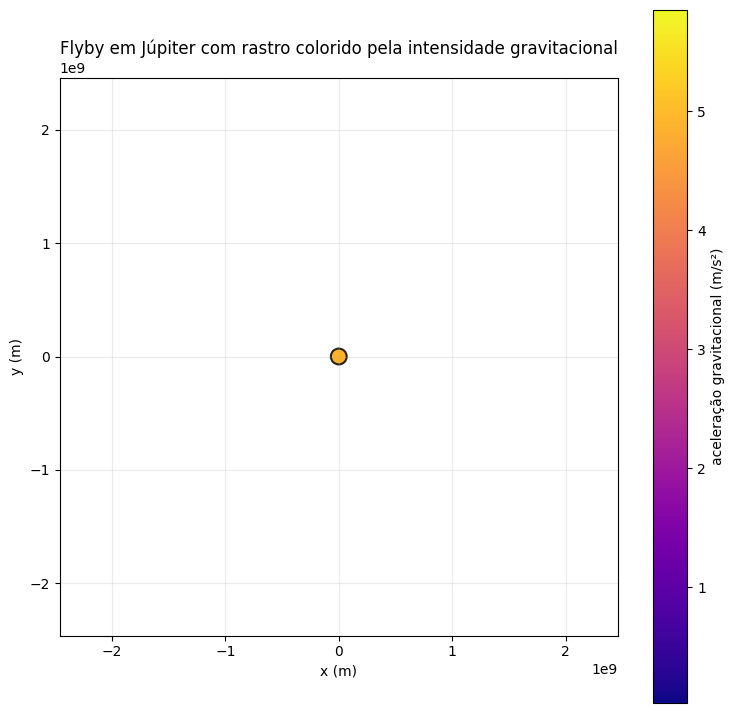


Resumo da simulação
---------------------------------------------
Gravidade na superfície da Terra   : 9.82 m/s²
Gravidade na superfície de Júpiter : 25.92 m/s²
Maior aceleração na trajetória     : 5.85 m/s²
Menor distância da nave            : 2.10 Rj
A nave não colidiu com Júpiter.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# =========================
# Constantes
# =========================
G = 6.67430e-11
M_JUPITER = 1.898e27
R_JUPITER = 6.9911e7
M_EARTH = 5.9722e24
R_EARTH = 6.371e6

# =========================
# Condições iniciais para cenário de aproximação Terra-Júpiter simplificado
# (Nave começa mais distante, simulando fase final de transferência)
# =========================
r0 = np.array([-30 * R_JUPITER, 10 * R_JUPITER], dtype=float) # Mais distante e ligeiramente fora do eixo
v0 = np.array([25000.0, -5000.0], dtype=float)   # Velocidade inicial mais baixa, com componente Y para interceptar

dt = 20.0
steps = 5000

# =========================
# Funções
# =========================
def acceleration(r):
    dist = np.linalg.norm(r)
    if dist == 0:
        return np.zeros(2)
    return -G * M_JUPITER * r / dist**3

def rk4_step(r, v, dt):
    def f_r(vv):
        return vv

    def f_v(rr):
        return acceleration(rr)

    k1_r = f_r(v)
    k1_v = f_v(r)

    k2_r = f_r(v + 0.5 * dt * k1_v)
    k2_v = f_v(r + 0.5 * dt * k1_r)

    k3_r = f_r(v + 0.5 * dt * k2_v)
    k3_v = f_v(r + 0.5 * dt * k2_r)

    k4_r = f_r(v + dt * k3_v)
    k4_v = f_v(r + dt * k3_r)

    r_next = r + (dt / 6.0) * (k1_r + 2*k2_r + 2*k3_r + k4_r)
    v_next = v + (dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
    return r_next, v_next

def gravity_magnitude(r):
    d = np.linalg.norm(r)
    return G * M_JUPITER / d**2

def surface_gravity(M, R):
    return G * M / R**2

def make_colored_line(ax, x, y, values, cmap="plasma", lw=2.5):
    """
    Cria um rastro colorido com base em values.
    """
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=np.min(values), vmax=np.max(values))
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(values[:-1])
    lc.set_linewidth(lw)
    ax.add_collection(lc)
    return lc

# =========================
# Simulação
# =========================
positions = []
velocities = []
accels = []
distances = []
times = []

r = r0.copy()
v = v0.copy()

collision = False
collision_step = None

for i in range(steps):
    positions.append(r.copy())
    velocities.append(v.copy())
    accels.append(np.linalg.norm(acceleration(r)))
    distances.append(np.linalg.norm(r))
    times.append(i * dt)

    if np.linalg.norm(r) <= R_JUPITER:
        collision = True
        collision_step = i
        break

    r, v = rk4_step(r, v, dt)

positions = np.array(positions)
velocities = np.array(velocities)
accels = np.array(accels)
distances = np.array(distances)
times = np.array(times)

# =========================
# Métricas
# =========================
g_earth_surface = surface_gravity(M_EARTH, R_EARTH)
g_jupiter_surface = surface_gravity(M_JUPITER, R_JUPITER)
max_accel = np.max(accels)
min_dist = np.min(distances)

# =========================
# Figura principal
# =========================
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2)

# -------------------------
# 1) Trajetória colorida
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Trajetória da nave com rastro colorido pela gravidade")

# Júpiter preenchido com cor
jupiter = plt.Circle(
    (0, 0),
    R_JUPITER,
    color="orange",
    alpha=0.85,
    ec="black",
    lw=1.5
)
ax1.add_patch(jupiter)

# rastro colorido
lc = make_colored_line(
    ax1,
    positions[:, 0],
    positions[:, 1],
    accels,
    cmap="plasma",
    lw=2.8
)

# ponto inicial
ax1.scatter(positions[0, 0], positions[0, 1], s=55, c="cyan", edgecolors="black", label="início")
ax1.scatter(positions[-1, 0], positions[-1, 1], s=55, c="white", edgecolors="black", label="fim")

limit = max(np.max(np.abs(positions[:, 0])), np.max(np.abs(positions[:, 1])), 32 * R_JUPITER) # Ajustado limite para nova distância
ax1.set_xlim(-1.1 * limit, 1.1 * limit)
ax1.set_ylim(-1.1 * limit, 1.1 * limit)
ax1.set_aspect("equal", adjustable="box")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="upper right")

cbar1 = fig.colorbar(lc, ax=ax1)
cbar1.set_label("aceleração gravitacional (m/s²)")

# -------------------------
# 2) Aceleração no tempo
# -------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Aceleração gravitacional ao longo do tempo")
ax2.plot(times / 60.0, accels, lw=2)
ax2.set_xlabel("tempo (min)")
ax2.set_ylabel("aceleração (m/s²)")
ax2.grid(True, alpha=0.3)

# -------------------------
# 3) Distância ao centro
# -------------------------
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Distância da nave ao centro de Júpiter")
ax3.plot(times / 60.0, distances / R_JUPITER, lw=2)
ax3.axhline(1.0, linestyle="--", lw=1.5, label="superfície de Júpiter")
ax3.set_xlabel("tempo (min)")
ax3.set_ylabel("distância (em raios de Júpiter)")
ax3.grid(True, alpha=0.3)
ax3.legend()

# -------------------------
# 4) Comparação de gravidade
# -------------------------
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_title("Comparação de gravidade")
labels = ["Terra\n(superfície)", "Júpiter\n(superfície)", "Máx. na\ntrajetória"]
values = [g_earth_surface, g_jupiter_surface, max_accel]
bars = ax4.bar(labels, values)
ax4.set_ylabel("aceleração (m/s²)")
ax4.grid(True, axis="y", alpha=0.3)

for bar, val in zip(bars, values):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# =========================
# Animação com rastro crescente
# =========================
fig2, ax = plt.subplots(figsize=(9, 9))
ax.set_title("Flyby em Júpiter com rastro colorido pela intensidade gravitacional")

jupiter2 = plt.Circle(
    (0, 0),
    R_JUPITER,
    color="orange",
    alpha=0.85,
    ec="black",
    lw=1.5
)
ax.add_patch(jupiter2)

ax.set_xlim(-1.1 * limit, 1.1 * limit)
ax.set_ylim(-1.1 * limit, 1.1 * limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.grid(True, alpha=0.25)

ship, = ax.plot([], [], marker="o", markersize=7, color="white", markeredgecolor="black")

norm = Normalize(vmin=np.min(accels), vmax=np.max(accels))
trail_lc = LineCollection([], cmap="plasma", norm=norm, linewidths=2.8)
trail_lc.set_array(np.array([]))
ax.add_collection(trail_lc)

cbar2 = fig2.colorbar(trail_lc, ax=ax)
cbar2.set_label("aceleração gravitacional (m/s²)")

def init():
    trail_lc.set_segments([])
    trail_lc.set_array(np.array([]))
    ship.set_data([], [])
    return trail_lc, ship

def update(frame):
    if frame < 2:
        ship.set_data([positions[frame, 0]], [positions[frame, 1]])
        return trail_lc, ship

    pts = positions[:frame]
    vals = accels[:frame]

    points = pts.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    trail_lc.set_segments(segments)
    trail_lc.set_array(vals[:-1])

    ship.set_data([positions[frame, 0]], [positions[frame, 1]])
    return trail_lc, ship

ani = FuncAnimation(
    fig2,
    update,
    frames=len(positions),
    init_func=init,
    interval=20,
    blit=True
)

plt.show()

# =========================
# Resumo
# =========================
print("\nResumo da simulação")
print("-" * 45)
print(f"Gravidade na superfície da Terra   : {g_earth_surface:.2f} m/s²")
print(f"Gravidade na superfície de Júpiter : {g_jupiter_surface:.2f} m/s²")
print(f"Maior aceleração na trajetória     : {max_accel:.2f} m/s²")
print(f"Menor distância da nave            : {min_dist / R_JUPITER:.2f} Rj")

if collision:
    print(f"A nave colidiu com Júpiter no passo {collision_step}.")
else:
    print("A nave não colidiu com Júpiter.")

### Simulação de Série Temporal: Viagem da Artemis até o Flyby de Júpiter

Estes gráficos mostram a evolução da aceleração gravitacional experimentada pela nave e sua distância ao centro de Júpiter ao longo do tempo. É possível observar como a aceleração aumenta significativamente à medida que a nave se aproxima do planeta, e como a distância varia durante a manobra de flyby.

### Velocidade de Escape no Ponto de Maior Aproximação

A velocidade de escape é a velocidade mínima que um objeto precisa para escapar da influência gravitacional de um corpo massivo, partindo de uma certa distância, sem mais propulsão. Vamos calcular esse valor no ponto de maior aproximação da nave com Júpiter durante a simulação.

In [5]:
import numpy as np

# Constantes já definidas na simulação anterior:
# G = 6.67430e-11
# M_JUPITER = 1.898e27
# min_dist (ponto de maior aproximação)

v_escape_min_dist = np.sqrt((2 * G * M_JUPITER) / min_dist)

print(f"Velocidade de escape no ponto de maior aproximação: {v_escape_min_dist:.2f} m/s")
print(f"Isso equivale a aproximadamente {v_escape_min_dist / 1000:.2f} km/s")

Velocidade de escape no ponto de maior aproximação: 51206.26 m/s
Isso equivale a aproximadamente 51.21 km/s


### Velocidade da Nave ao Longo do Tempo

Este gráfico mostra como a magnitude da velocidade da nave varia durante a simulação. É possível observar o aumento da velocidade à medida que a nave se aproxima de Júpiter e a diminuição após o ponto de maior aproximação, devido à aceleração e desaceleração gravitacional.

### Comparação de Aceleração e Velocidade ao Longo do Tempo

Este gráfico visualiza a relação entre a aceleração gravitacional e a magnitude da velocidade da nave. É possível observar como a aceleração (força gravitacional) influencia as mudanças na velocidade da nave durante o flyby.

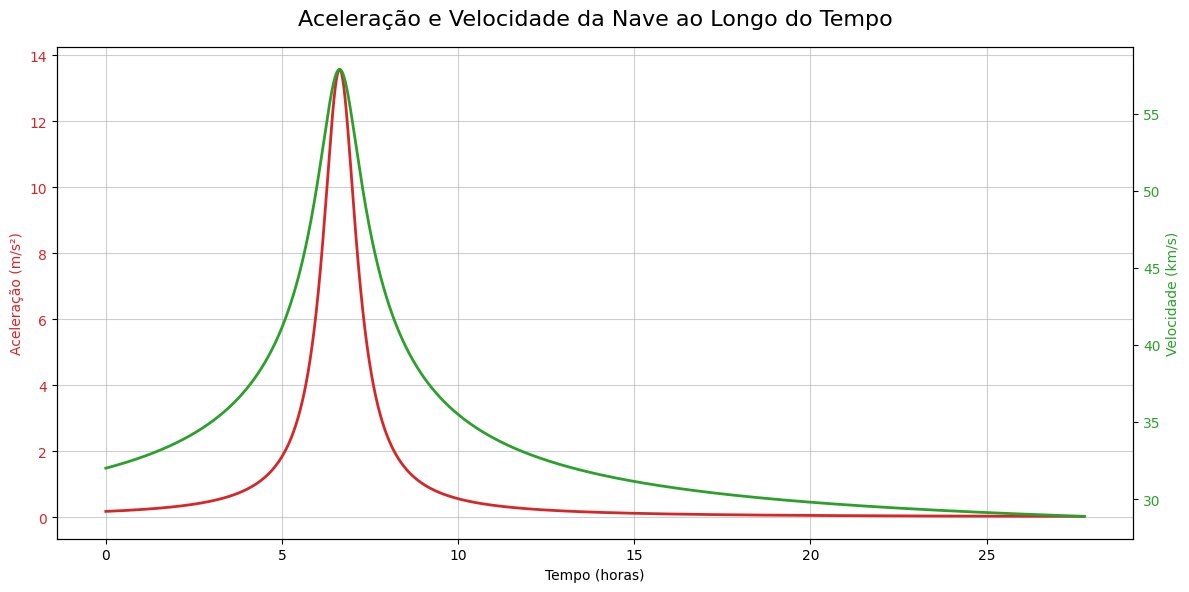

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 'times', 'accels', e 'velocity_magnitudes' estão disponíveis do código executado anteriormente.

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotar aceleração no eixo y primário
color = 'tab:red'
ax1.set_xlabel('Tempo (horas)')
ax1.set_ylabel('Aceleração (m/s²)', color=color)
ax1.plot(times / 3600, accels, color=color, linewidth=2, label='Aceleração')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.6)

# Criar um segundo eixo y para a velocidade
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Velocidade (km/s)', color=color)
ax2.plot(times / 3600, velocity_magnitudes / 1000, color=color, linewidth=2, label='Velocidade') # Converter para km/s
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Aceleração e Velocidade da Nave ao Longo do Tempo', fontsize=16)
fig.tight_layout()  # Ajustar layout para evitar sobreposição
plt.show()


### Variação da Energia Cinética da Nave

Vamos calcular a energia cinética da nave no início e no final da simulação para entender a variação de energia causada pela interação gravitacional com Júpiter. A energia cinética é calculada como $E_k = \frac{1}{2}mv^2$.

In [8]:
import numpy as np

# Constantes e variáveis disponíveis:
# M_SHIP (massa da nave)
# v0 (velocidade inicial da nave)
# velocities (array de velocidades, o último elemento é a velocidade final)

# Velocidade inicial (magnitude)
v_initial = np.linalg.norm(v0)

# Velocidade final (magnitude)
v_final = np.linalg.norm(velocities[-1])

# Energia cinética inicial
kinetic_energy_initial = 0.5 * M_SHIP * (v_initial**2)

# Energia cinética final
kinetic_energy_final = 0.5 * M_SHIP * (v_final**2)

# Variação da energia cinética
delta_kinetic_energy = kinetic_energy_final - kinetic_energy_initial

print(f"Massa da Nave: {M_SHIP} kg")
print(f"Velocidade Inicial da Nave: {v_initial:.2f} m/s")
print(f"Velocidade Final da Nave: {v_final:.2f} m/s")
print(f"Energia Cinética Inicial: {kinetic_energy_initial:.2e} Joules")
print(f"Energia Cinética Final: {kinetic_energy_final:.2e} Joules")
print(f"Variação da Energia Cinética (Final - Inicial): {delta_kinetic_energy:.2e} Joules")

if delta_kinetic_energy > 0:
    print("A nave ganhou energia cinética durante o flyby.")
elif delta_kinetic_energy < 0:
    print("A nave perdeu energia cinética durante o flyby.")
else:
    print("A energia cinética da nave permaneceu a mesma.")


Massa da Nave: 26000 kg
Velocidade Inicial da Nave: 32000.00 m/s
Velocidade Final da Nave: 28872.81 m/s
Energia Cinética Inicial: 1.33e+13 Joules
Energia Cinética Final: 1.08e+13 Joules
Variação da Energia Cinética (Final - Inicial): -2.47e+12 Joules
A nave perdeu energia cinética durante o flyby.


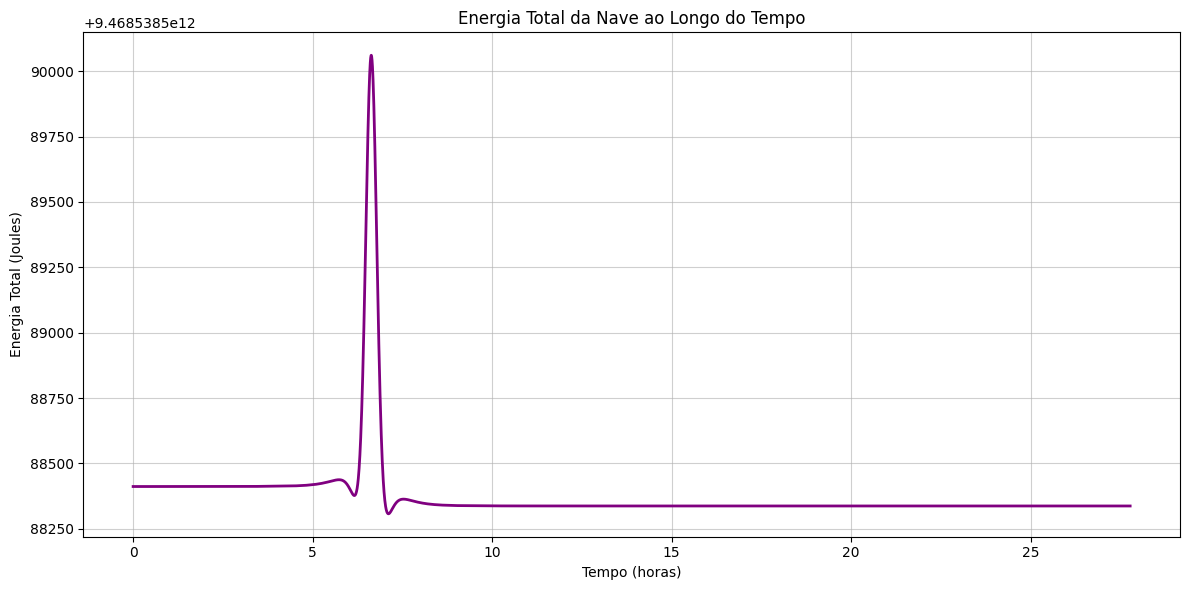

Variação percentual máxima na energia total: 0.0000%
Uma variação muito pequena indica que a energia é bem conservada, o que é esperado para este tipo de simulação sem forças dissipativas.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# As variáveis 'times', 'positions', 'velocities', 'M_SHIP', 'G', 'M_JUPITER' já estão disponíveis do kernel.

# Calcular a energia cinética para cada passo da simulação
kinetic_energies = 0.5 * M_SHIP * np.linalg.norm(velocities, axis=1)**2

# Calcular a energia potencial para cada passo da simulação
# U = -G * M_JUPITER * M_SHIP / r
distances_from_center = np.linalg.norm(positions, axis=1)
potential_energies = -G * M_JUPITER * M_SHIP / distances_from_center

# Calcular a energia total
total_energies = kinetic_energies + potential_energies

# Plotar a energia total ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(times / 3600, total_energies, linewidth=2, color='purple') # Tempo em horas
ax.set_title('Energia Total da Nave ao Longo do Tempo')
ax.set_xlabel('Tempo (horas)')
ax.set_ylabel('Energia Total (Joules)')
ax.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

# Exibir a variação percentual máxima da energia total
initial_total_energy = total_energies[0]
max_deviation = np.max(np.abs(total_energies - initial_total_energy)) / initial_total_energy * 100

print(f"Variação percentual máxima na energia total: {max_deviation:.4f}%")
print("Uma variação muito pequena indica que a energia é bem conservada, o que é esperado para este tipo de simulação sem forças dissipativas.")

### Entendendo a Assistência Gravitacional (Gravity Assist ou Slingshot)

A assistência gravitacional, também conhecida como manobra de estilingue gravitacional ou *gravity assist*, é uma técnica utilizada em missões espaciais para acelerar ou desacelerar uma espaçonave, ou para mudar sua trajetória, usando a gravidade de um planeta (ou outro corpo celeste) em movimento.

**Como funciona:**

1.  **Aproximação:** A espaçonave se aproxima de um planeta. Do ponto de vista do planeta, a nave se aproxima e se afasta com a mesma velocidade (considerando apenas a interação nave-planeta e ignorando o Sol). No entanto, do ponto de vista do Sol, o planeta está se movendo.

2.  **Interação Gravitacional:** A gravidade do planeta puxa a espaçonave, acelerando-a enquanto ela se aproxima e desacelerando-a enquanto ela se afasta. Durante essa interação, a nave "rouba" (ou "cede") uma pequena quantidade de energia orbital do (ou para o) planeta.

3.  **Mudança de Velocidade e Trajetória:** Como o planeta está em movimento orbital em torno do Sol, a nave interage com o campo gravitacional do planeta e, de certa forma, "pega carona" na sua velocidade. Isso faz com que a velocidade da nave em relação ao Sol aumente (ou diminua, dependendo do ângulo de aproximação) e sua trajetória seja curvada.

**Pontos Chave:**

*   **Conservação de Energia:** A energia total do sistema (nave + planeta + Sol) é conservada. A pequena mudança na energia da nave é compensada por uma mudança minúscula e imperceptível na energia do planeta.
*   **Eficiência:** É uma forma extremamente eficiente de economizar combustível, pois a energia para a mudança de velocidade vem do movimento orbital do planeta, e não dos propulsores da espaçonave.
*   **Não é "de graça"**: Embora não use combustível da nave, a manobra exige um planejamento de trajetória extremamente preciso e uma janela de lançamento muito específica para que a nave e o planeta se encontrem no momento e local corretos.

No nosso caso, a simulação mostra a interação gravitacional da nave com Júpiter, resultando em uma mudança na velocidade e na trajetória da nave. Se a nave ganha ou perde energia cinética em relação ao Sol depende do vetor de velocidade inicial e da geometria da manobra.

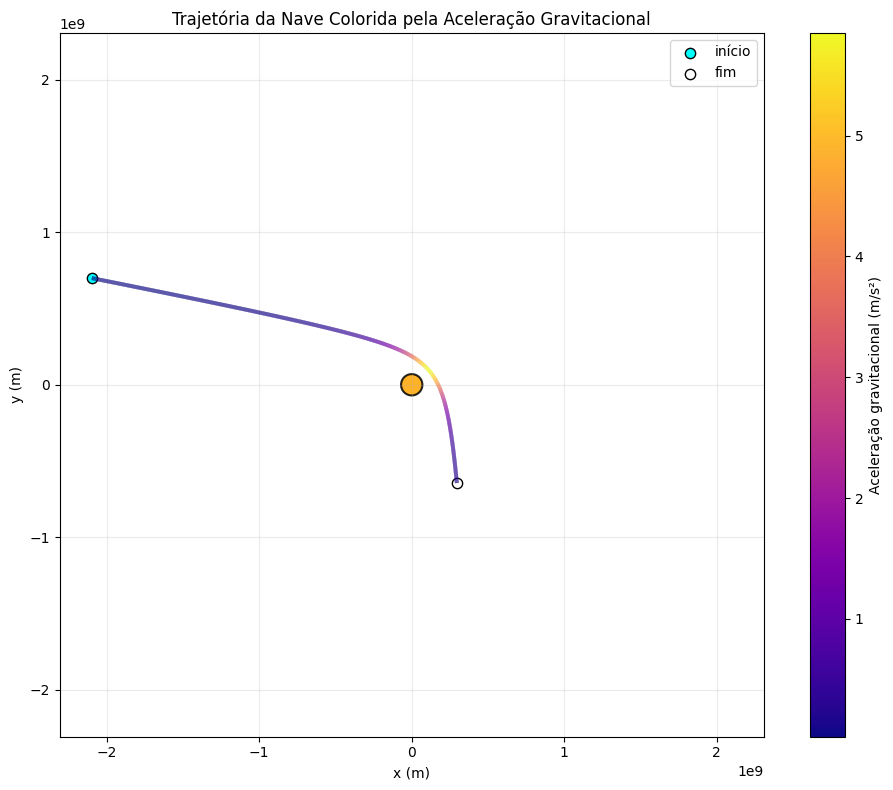

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# Re-define make_colored_line as it's a custom helper function
def make_colored_line(ax, x, y, values, cmap="plasma", lw=2.5):
    """
    Cria um rastro colorido com base em values.
    """
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=np.min(values), vmax=np.max(values))
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(values[:-1])
    lc.set_linewidth(lw)
    ax.add_collection(lc)
    return lc

# Assuming 'positions', 'accels', and 'R_JUPITER' are available from previous runs
# If not, the user would need to run the simulation cell (vEZTxcWDpZlV) first.

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title("Trajetória da Nave Colorida pela Aceleração Gravitacional")

# Júpiter preenchido com cor
jupiter = plt.Circle(
    (0, 0),
    R_JUPITER,
    color="orange",
    alpha=0.85,
    ec="black",
    lw=1.5
)
ax.add_patch(jupiter)

# rastro colorido
lc = make_colored_line(
    ax,
    positions[:, 0],
    positions[:, 1],
    accels,
    cmap="plasma",
    lw=2.8
)

# ponto inicial
ax.scatter(positions[0, 0], positions[0, 1], s=55, c="cyan", edgecolors="black", label="início")
ax.scatter(positions[-1, 0], positions[-1, 1], s=55, c="white", edgecolors="black", label="fim")

# Ajustar limites do gráfico
# Use 'limit' if it's available and makes sense, otherwise recalculate based on positions
max_coord = max(np.max(np.abs(positions[:, 0])), np.max(np.abs(positions[:, 1])), 5 * R_JUPITER) # Adjusted for potential smaller trajectories
ax.set_xlim(-1.1 * max_coord, 1.1 * max_coord)
ax.set_ylim(-1.1 * max_coord, 1.1 * max_coord)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")

cbar = fig.colorbar(lc, ax=ax)
cbar.set_label("Aceleração gravitacional (m/s²)")

plt.tight_layout()
plt.show()